#Simple Linear Regressor from scratch using closed loop solution

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Getting the available dataset name from the seaborn

In [11]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

#Loading tips dataset into dataframe tips

In [12]:
tips=sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


#Data visualization

<Axes: xlabel='total_bill', ylabel='tip'>

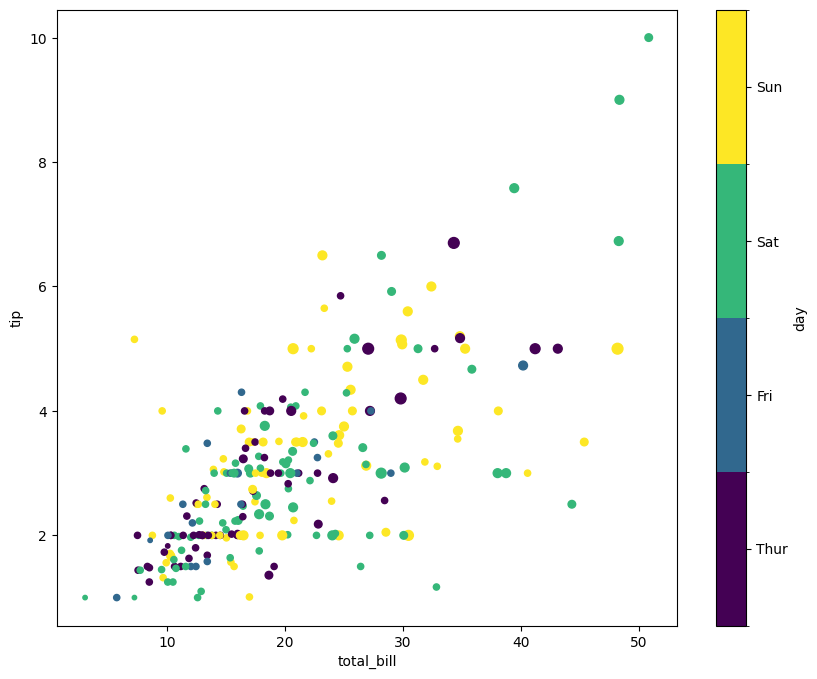

In [13]:
tips.plot.scatter(x='total_bill', y='tip', style='sex',s=(tips['size'].values)*10 , c='day', cmap='viridis',figsize=(10,8))

#Using only two columns of the dataset

In [14]:
x=tips['total_bill'].values
y=tips['tip'].values

Text(0.5, 1.0, 'total_bill(x) vs tip(y)')

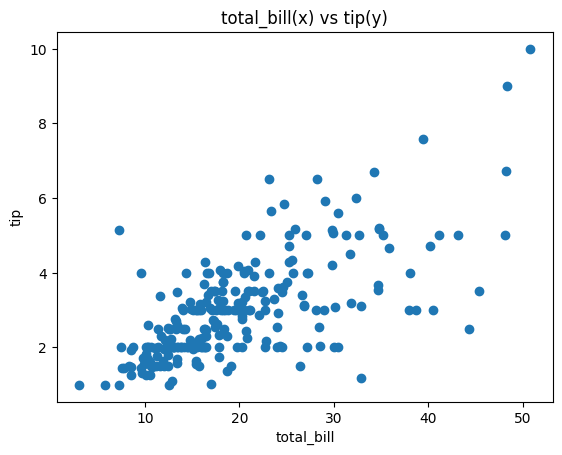

In [15]:
plt.scatter(x,y)
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.title('total_bill(x) vs tip(y)')

#making simple regressor class using closed looped solution

In [16]:
class ClosedLoopLinearRegressor:
    def __init__(self):
        pass
    
    def fit(self, x_train, y_train):
        self.x_train=x_train
        self.y_train=y_train
        num=0
        den=0
        for i in range(x_train.shape[0]):
            num=num+(y_train[i]-y_train.mean())*(x_train[i]-x_train.mean())
            den=den+(x_train[i]-x_train.mean())**2
        self.slope_=num/den
        self.intercept_=y_train.mean()-self.slope_*x_train.mean()
    
    def predict(self,x_test):
        return self.slope_*x_test+self.intercept_


In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape)
print(y_train.shape)

(195,)
(195,)


In [18]:
linear=ClosedLoopLinearRegressor()
linear.fit(x_train, y_train)
y_predict=linear.predict(x_test)
y_predict

array([3.04525623, 1.86330727, 3.55119456, 3.69452593, 2.31576375,
       2.83881627, 3.96728338, 2.26014262, 2.50615915, 2.57033737,
       2.88160176, 2.07723468, 2.06439904, 2.47407003, 2.00236009,
       2.91903905, 2.92652651, 3.23351235, 2.68478854, 5.33107064,
       3.13831465, 3.13403611, 2.4558862 , 1.94673896, 3.16077703,
       2.17564129, 2.02375283, 3.62927807, 2.68906708, 6.07767732,
       4.99734388, 1.75313465, 2.83025918, 3.09552917, 2.74040966,
       3.50092162, 2.21200895, 5.53644096, 2.33287794, 3.35010279,
       2.04942412, 2.47834858, 3.48701634, 2.03017065, 2.03124029,
       1.25361414, 2.05798121, 2.92438724, 1.73388118])

#checking the fitted line on test dataset

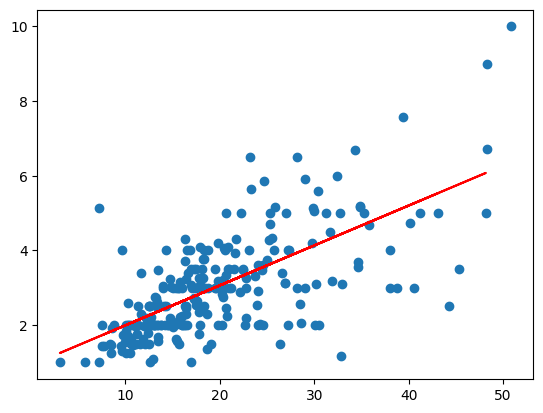

In [19]:
plt.scatter(x,y)
plt.plot(x_test,y_predict,c='r')

In [20]:
print(linear.intercept_)
print(linear.slope_)

0.9252355585570555
0.10696370685268661


#validation with test data

In [21]:
print(y_test)
print(y_predict)

[3.18 2.   2.   5.16 2.   2.   2.56 2.52 3.23 3.   3.   1.47 1.5  2.
 1.83 1.36 4.   3.92 2.47 5.   2.45 3.35 4.   1.45 3.5  2.31 1.71 5.
 2.   5.   4.   1.44 2.34 3.21 3.5  2.92 1.5  5.   2.75 2.   1.25 2.
 2.55 1.67 2.   1.   1.61 2.31 1.44]
[3.04525623 1.86330727 3.55119456 3.69452593 2.31576375 2.83881627
 3.96728338 2.26014262 2.50615915 2.57033737 2.88160176 2.07723468
 2.06439904 2.47407003 2.00236009 2.91903905 2.92652651 3.23351235
 2.68478854 5.33107064 3.13831465 3.13403611 2.4558862  1.94673896
 3.16077703 2.17564129 2.02375283 3.62927807 2.68906708 6.07767732
 4.99734388 1.75313465 2.83025918 3.09552917 2.74040966 3.50092162
 2.21200895 5.53644096 2.33287794 3.35010279 2.04942412 2.47834858
 3.48701634 2.03017065 2.03124029 1.25361414 2.05798121 2.92438724
 1.73388118]


#calculating the means square average error

In [22]:
def mean_average_error(y_test, y_predict):
    return ((abs(y_test-y_predict)).mean())

In [23]:
mean_average_error(y_test, y_predict)

np.float64(0.6208580000398983)

#Calculating mean square error

In [24]:
def mean_square_error(y_test, y_predict):
    return (((y_test-y_predict)**2).mean())

In [25]:
mean_square_error(y_test, y_predict)

np.float64(0.5688142529229538)

#Calculating  root mean square error

In [26]:
def root_mean_square_error(y_test, y_predict):
    return np.sqrt(((y_test-y_predict)**2).mean())
    

In [27]:
root_mean_square_error(y_test, y_predict)

np.float64(0.7541977545199626)

#calculating r_2 score

In [28]:
def r2_score(y_test, y_predict):
    ssr = np.sum((y_test - y_predict) ** 2)
    ssm = np.sum((y_test - np.mean(y_test)) ** 2)

    return 1 - (ssr / ssm)

In [29]:
r2_score(y_test, y_predict)

np.float64(0.5449381659234664)